In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)


Matplotlib is building the font cache; this may take a moment.


In [2]:
retail_price = pd.read_csv(
    PROCESSED_DATA / "retail_price_clean.csv", parse_dates=["month_year"]
)

inventory = pd.read_csv(PROCESSED_DATA / "inventory_clean.csv", parse_dates=["date"])

online_retail = pd.read_csv(
    PROCESSED_DATA / "online_retail_clean.csv", parse_dates=["invoicedate"]
)

print(retail_price.shape)
print(inventory.shape)
print(online_retail.shape)


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19020\1208191398.py:7: DtypeWarning: Columns (0: invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  online_retail = pd.read_csv(


(676, 30)
(73100, 15)
(1007913, 9)


In [3]:
print("Products:", retail_price["product_id"].nunique())
print("Categories:", retail_price["product_category_name"].nunique())

display(retail_price["product_category_name"].value_counts())


Products: 52
Categories: 9


product_category_name
garden_tools             160
health_beauty            130
watches_gifts            103
computers_accessories     69
bed_bath_table            61
cool_stuff                57
furniture_decor           48
perfumery                 26
consoles_games            22
Name: count, dtype: int64

In [4]:
display(
    retail_price[["qty", "unit_price", "total_price", "freight_price"]].describe().T
)


,count,mean,std,min,25%,50%,75%,max
qty,676.0,14.495562,15.443421,1.0,4.000000,10.000000,18.000000,122.00
unit_price,676.0,106.496800,76.182972,19.9,53.900000,89.900000,129.990000,364.00
total_price,676.0,1422.708728,1700.123100,19.9,333.700000,807.890000,1887.322500,12095.00
freight_price,676.0,20.682270,10.081817,0.0,14.761912,17.518472,22.713558,79.76


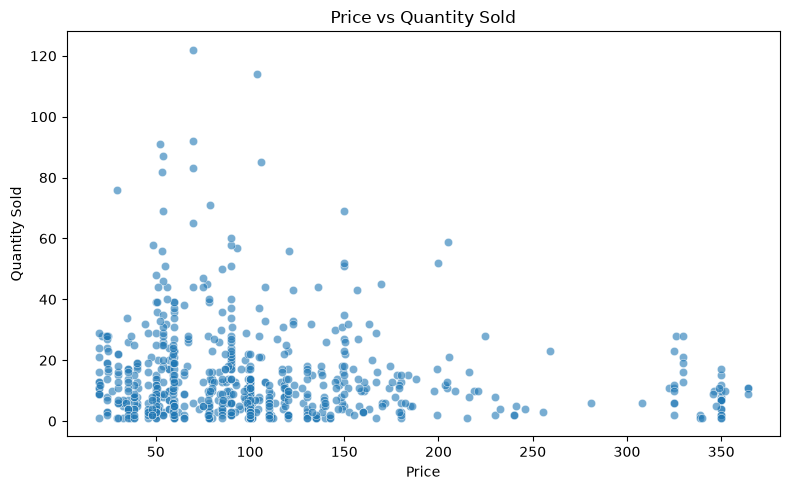

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=retail_price, x="unit_price", y="qty", alpha=0.6)

plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.tight_layout()

plt.savefig(FIGURES / "price_vs_quantity.png", dpi=150)

plt.show()


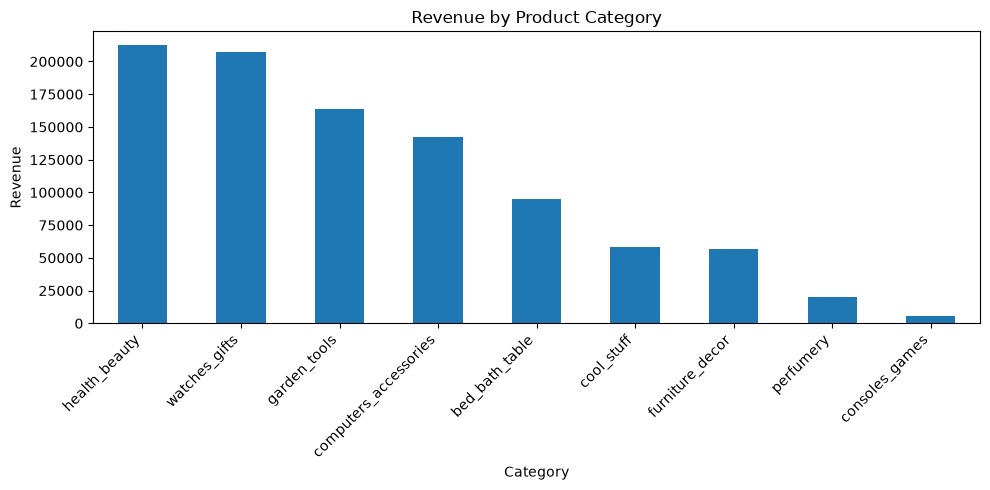

In [7]:
category_revenue = (
    retail_price.groupby("product_category_name")["total_price"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(FIGURES / "revenue_by_category.png", dpi=150)

plt.show()


In [8]:
print("Stores:", inventory["store_id"].nunique())
print("Products:", inventory["product_id"].nunique())
print("Categories:", inventory["category"].nunique())

display(
    inventory[
        [
            "inventory_level",
            "units_sold",
            "units_ordered",
            "demand_forecast",
            "price",
            "discount",
            "competitor_pricing",
        ]
    ]
    .describe()
    .T
)


Stores: 5
Products: 20
Categories: 5


,count,mean,std,min,25%,50%,75%,max
inventory_level,73100.0,274.469877,129.949514,50.00,162.00,273.000,387.0000,500.00
units_sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
units_ordered,73100.0,110.004473,52.277448,20.00,65.00,110.000,155.0000,200.00
demand_forecast,73100.0,141.494720,109.254076,-9.99,53.67,113.015,208.0525,518.55
price,73100.0,55.135108,26.021945,10.00,32.65,55.050,77.8600,100.00
discount,73100.0,10.009508,7.083746,0.00,5.00,10.000,15.0000,20.00
competitor_pricing,73100.0,55.146077,26.191408,5.03,32.68,55.010,77.8200,104.94


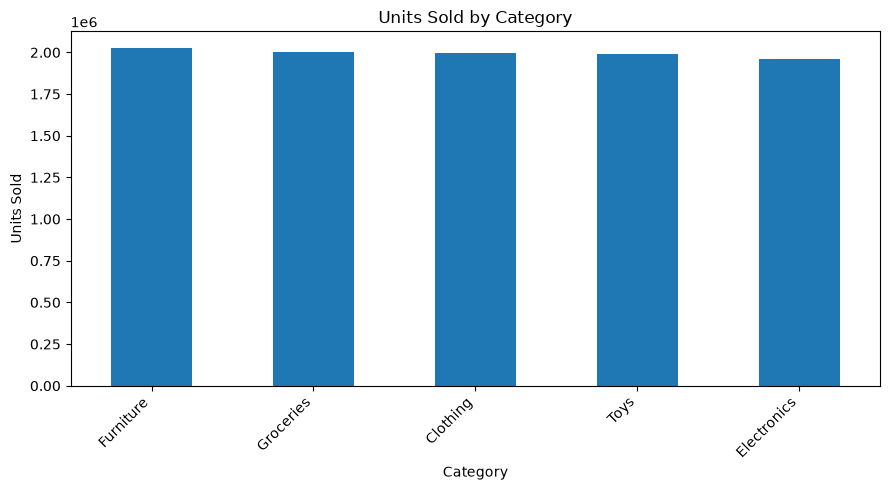

In [9]:
category_sales = (
    inventory.groupby("category")["units_sold"].sum().sort_values(ascending=False)
)

category_sales.plot(kind="bar", figsize=(9, 5))

plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


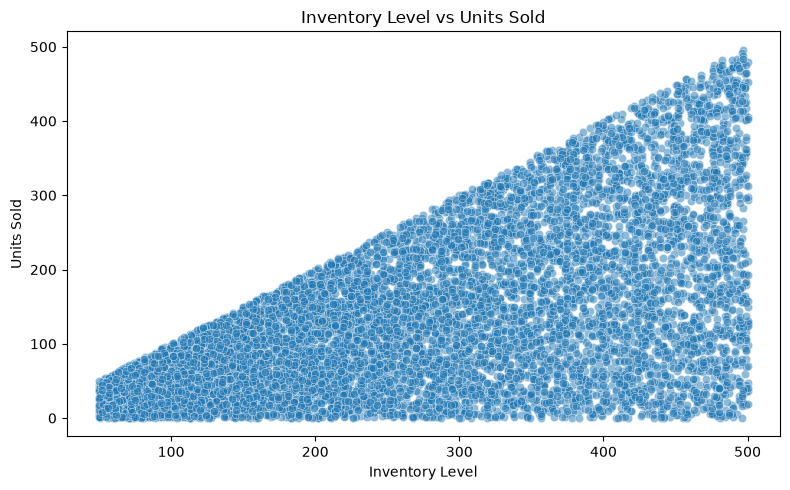

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=inventory.sample(min(10000, len(inventory)), random_state=42),
    x="inventory_level",
    y="units_sold",
    alpha=0.5,
)

plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.tight_layout()

plt.show()


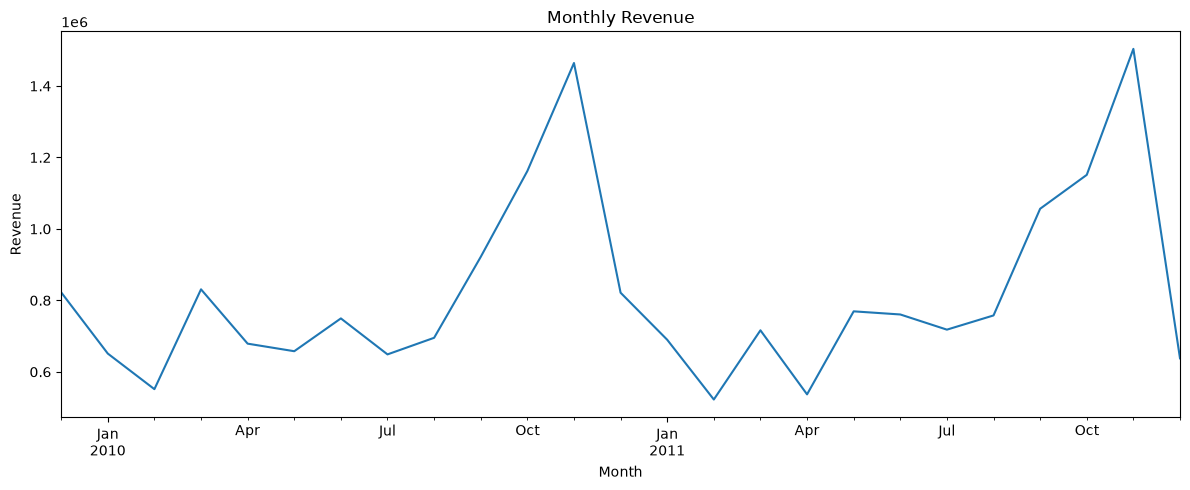

In [11]:
monthly_revenue = online_retail.set_index("invoicedate").resample("MS")["revenue"].sum()

plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()

plt.savefig(FIGURES / "monthly_revenue.png", dpi=150)

plt.show()


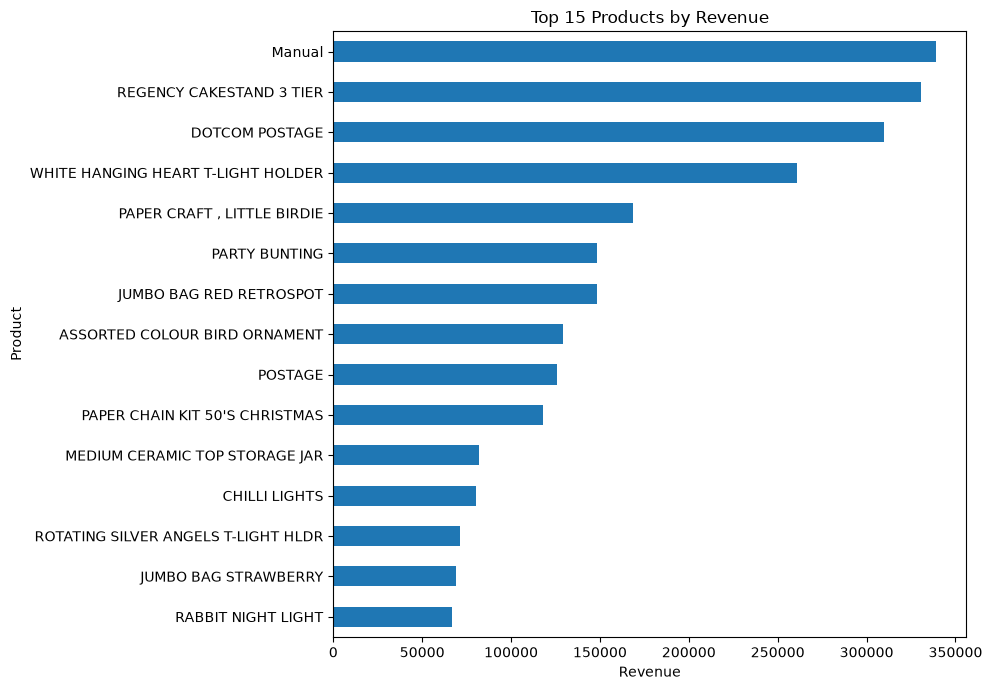

In [12]:
top_products = (
    online_retail.groupby("description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_products.sort_values().plot(kind="barh", figsize=(10, 7))

plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


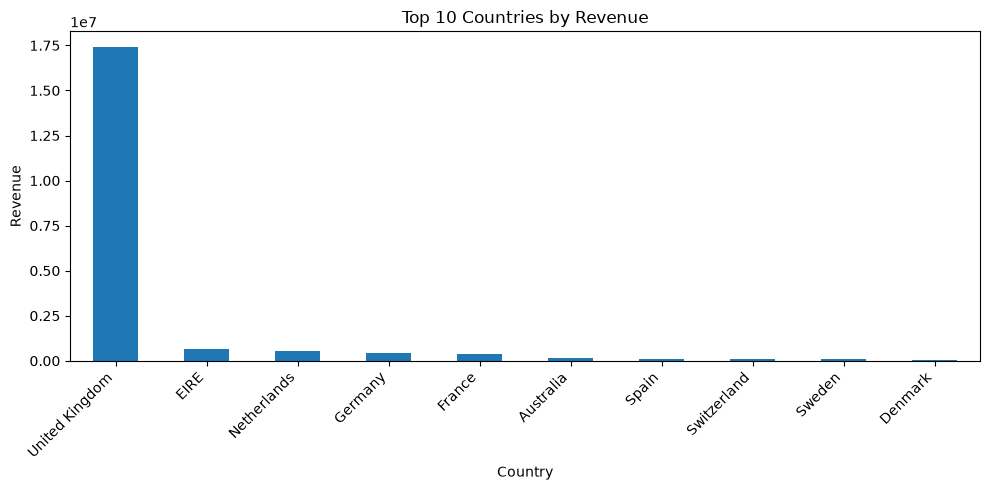

In [13]:
top_countries = (
    online_retail.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [14]:
price_demand_corr = retail_price[["qty", "unit_price", "total_price"]].corr()

display(price_demand_corr)


,qty,unit_price,total_price
qty,1.000000,-0.103432,0.749605
unit_price,-0.103432,1.000000,0.409001
total_price,0.749605,0.409001,1.000000


In [15]:
retail_price["comp_1_diff"] = retail_price["unit_price"] - retail_price["comp_1"]

display(
    retail_price[["unit_price", "comp_1", "comp_2", "comp_3", "comp_1_diff"]]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
unit_price,676.0,106.496800,76.182972,19.9,53.900000,89.90,129.990000,364.00
comp_1,676.0,79.452054,47.933358,19.9,49.910000,69.90,104.256549,349.90
comp_2,676.0,92.930079,49.481269,19.9,53.900000,89.99,117.888889,349.90
comp_3,676.0,84.182642,47.745789,19.9,53.785714,59.90,99.990000,255.61
comp_1_diff,676.0,27.044746,76.062125,-85.0,0.000000,0.00,39.141667,340.01


In [16]:
inventory["competitor_price_gap"] = inventory["price"] - inventory["competitor_pricing"]

display(inventory[["price", "competitor_pricing", "competitor_price_gap"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
price,73100.0,55.135108,26.021945,10.00,32.65,55.05,77.86,100.00
competitor_pricing,73100.0,55.146077,26.191408,5.03,32.68,55.01,77.82,104.94
competitor_price_gap,73100.0,-0.010969,2.888538,-5.00,-2.53,0.00,2.50,5.00


In [17]:
inventory["forecast_error"] = inventory["units_sold"] - inventory["demand_forecast"]

inventory["absolute_forecast_error"] = inventory["forecast_error"].abs()

display(
    inventory[
        ["units_sold", "demand_forecast", "forecast_error", "absolute_forecast_error"]
    ]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
units_sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
demand_forecast,73100.0,141.494720,109.254076,-9.99,53.67,113.015,208.0525,518.55
forecast_error,73100.0,-5.029850,8.660766,-20.00,-12.51,-4.990,2.4700,10.00
absolute_forecast_error,73100.0,8.338076,5.548347,0.00,3.73,7.480,12.5100,20.00
